### Langchain version v1

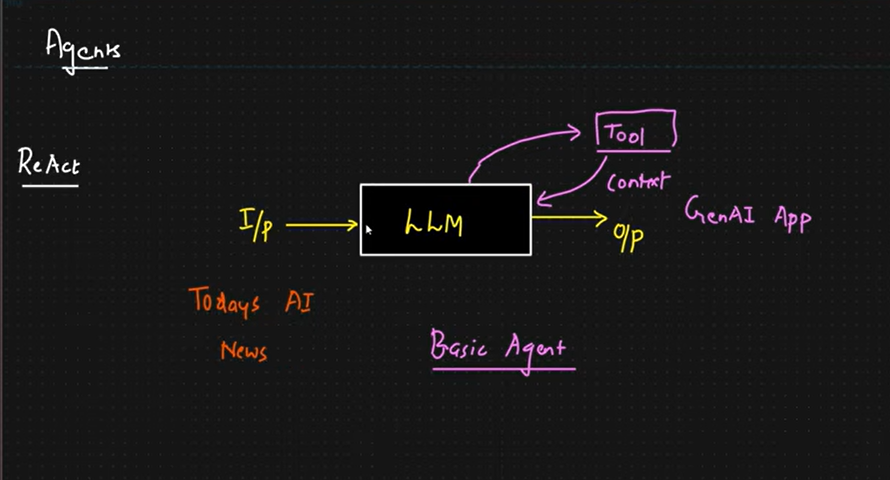

In [1]:
import langchain
langchain.__version__

'1.3.7'

In [3]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ['OPENROUTER_API_KEY'] = os.getenv('OPENROUTER_API_KEY')

In [6]:
from langchain_openrouter import ChatOpenRouter

model = ChatOpenRouter(
    ### model="nvidia/nemotron-3-ultra-550b-a55b:free"
    model = "openrouter/owl-alpha",
)

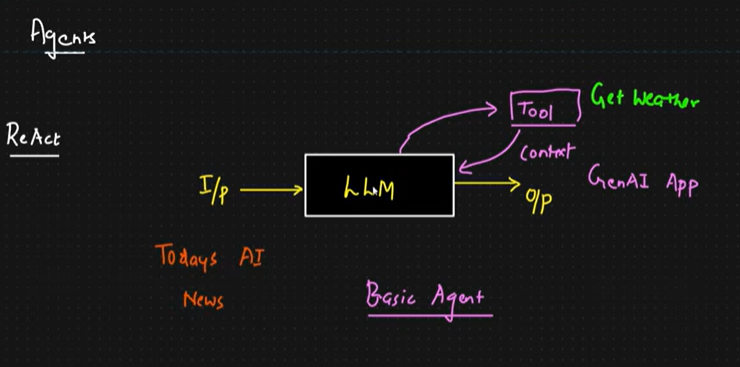

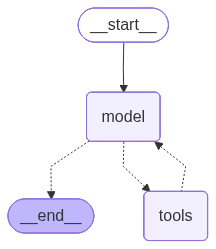

In [12]:
from langchain.agents import create_agent

def get_weather(city:str)->str:
    """Get the weather for a city"""
    return f"The weather in {city} is sunny"

agent = create_agent(
    model=model,
    tools=[get_weather],
    system_prompt="You are a helpful assistant"
)

agent

In [17]:
### Run the agent
response = agent.invoke({"messages":[{"role":"user","content":"What is the weather in New York"}]})

In [19]:
response["messages"][-1].content

'The weather in New York is sunny.'

### Models integration with OpenAI, Google Gemini and GROQ

In [ ]:
os.environ["OPENEAI_API_kEY"] = os.get_env("OPENAI_API_kEY")
os.environ["GOOGLE_API_kEY"] = os.get_env("GOOGLE_API_kEY")
os.environ["GROQ_API_kEY"] = os.get_env("GROQ_API_kEY")

* Both GPT and Gemini models can be import via below method but we have to <br> use the prefix google_genai: before the model address/name

In [ ]:
from langchain.chat_models import init_chat_models
model = init_chat_models("openrouter:openai/gpt-oss-20b:free")
model

* Due to the not availability of OpenAI, Gemini Api below methods are used

In [22]:
from langchain_openrouter import ChatOpenRouter
model = ChatOpenRouter(
    model = "openai/gpt-oss-20b:free"
)

In [23]:
response = model.invoke("Hello how are you")
response

AIMessage(content="Hello! I'm doing great—thanks for asking. How can I help you today?", additional_kwargs={'reasoning_content': 'Just greet.', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'Just greet.'}]}, response_metadata={'model_name': 'openai/gpt-oss-20b:free', 'id': 'gen-1781154735-kcaf4vBIiVSQJbGYtqQQ', 'created': 1781154735, 'object': 'chat.completion', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'openrouter'}, id='lc_run--019eb518-6294-7ed2-92b1-20d5968c9225-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 71, 'output_tokens': 30, 'total_tokens': 101, 'input_token_details': {'cache_read': 64, 'cache_creation': 0}, 'output_token_details': {'reasoning': 3}})

* ChatOPenAi


In [ ]:
from langchain_openai import ChatOpenAi

model = ChatOpenAi(model="")
response = model.invoke("Why do parrots fly")
response

* GoogleGenerativeAI

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
model = ChatGoogleGenerativeAI(model="")
response = model.invoke("")
response

* GROQ

In [ ]:
from langchain_groq import ChatGroq
model = ChatGroq(model="")
response = model.invoke("why parrots fly")
response

# Streaming and Batch


### Streaming
* Most models can stream their output content while its being generated. By displaying output progressively, streaming significantly improves user experience, partucularly for longer response. Calling sreamm() retuns an iterator that yields output chuncs as they are produced. You can use a loop to process each chinc in real-time

In [ ]:
model.invoke("Write a 10 words lines on AI")
### Proudces the output first and then display

In [7]:
for chunc in model.stream("Write me 50 words on AI"):
    print(chunc.text)

#
 The
 Rise of Artificial Intelligence


Artificial Intelligence
 is transforming our
 world at
 an unprecedented pace.
 From healthcare
 to transportation
, AI enhances
 efficiency and innovation
. Machine learning algorithms
 analyze vast data
, enabling smarter
 decisions. As technology
 evolves, ethical
 considerations become
 crucial. Bal
ancing progress
 with responsibility ensures AI
 benefits humanity,
 shaping
 a future where intelligence
—
both artificial
 and human—th
rives together.





In [8]:
for chunc in model.stream("Write me 100 words paragraph on AI"):
    print(chunc.text, end="|", flush=True)

Here| is| a 10|0-word paragraph on| AI:

Artificial| Intelligence is| transforming the world| as| we know it.| From healthcare| to finance|, AI is revolution|izing industries by autom|ating complex tasks and| providing| intelligent| solutions. Machine learning| algorithms analyze| vast amounts of data| to make predictions and| decisions| with| unprecedented| accuracy. Natural language| processing enables computers to| understand and generate human| language, while| computer| vision allows machines to| interpret visual information.| As| AI continues to evolve|, it promises to| enhance productivity, improve| quality| of life, and| solve| some of humanity|'s greatest challenges.| However, ethical considerations| around| bias, privacy,| and job displacement must| be carefully addressed| to ensure responsible development|.||||

In [9]:
for chunc in model.stream("Why do parrots have colorful feathers"):
    print(chunc.text, end="|", flush=True)

Par|rots| have colorful feathers for| several important| reasons:

1.| **Camouflage|**: In their| natural rainforest| habitats, bright colors| can actually| help them| blend in| with colorful| flowers|,| fruits, and foliage|.

2. **|Mate| Selection|**: Vibr|ant plum|age signals| health and genetic| fitness to| potential mates. Br|ighter colors often indicate| a| well-nourished|, parasite-free bird|.

3. **|Species Recognition**: Dist|inct color| patterns help par|rots identify members| of their own species|, which is crucial| for social| bonding and breeding|.

4. **|Communication|**: Feather| colors and| patterns| can convey information| about age|, sex, and| social status within parrot| fl|ocks.

5.| **UV| Signaling|**: Many parrots| can| see ultraviolet light|, and their feathers| may have UV|-ref|lective properties| invisible to humans| but important| for parrot|-to|-parrot communication.

|The specific| pigments| responsible| include:
- **|Psittacof|ulvins**| (unique to| par|rots)

### Batch
* Batching a collection of independent requests to a model can significatnly improve performance and reduce costs, as the processing can be done in parallel.

In [11]:
responses = model.batch([
    "Why do parrots have colorful feathers",
    "How do airplance fly",
    "What is AI"],
    config={
        'max_concurrency': 5, # limits to 5 parallels calls
    }
)
for response in responses:
    print(response)

content='Parrots have colorful feathers for several important reasons:\n\n1. **Camouflage**: In their natural rainforest habitats, bright colors can help parrots blend in with colorful flowers, fruits, and foliage, making it harder for predators to spot them.\n\n2. **Mate Selection**: Vibrant plumage often signals health and genetic fitness. Brighter colors can attract mates, as they may indicate a well-nourished, parasite-free individual.\n\n3. **Species Recognition**: Distinctive color patterns help parrots identify members of their own species, which is crucial for social bonding and avoiding hybridization.\n\n4. **Communication**: Feather colors and patterns can convey social signals—such as dominance, readiness to breed, or group identity—within flocks.\n\n5. **UV Signaling**: Some parrots have feathers that reflect ultraviolet light, invisible to humans but visible to other parrots, adding another layer of visual communication.\n\nSo, their dazzling feathers are not just for show